# PET REMOTE SYSTEM

- 반려동물 원격 진료 시스템

- 제미나이 1차 지피티 2차수정

## 0. 공통 라이브러리 설정

- 왜? 재현성(seed), 경고 최소화, 기본 세팅.

In [1]:
import os, json, math, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. 라벨 JSON 스키마 점검(빠른 스니핑)

- 왜? JSON 키 이름이 조금씩 다르면 바로 에러. 2~3개만 미리 훑어서 키 구조를 본다.

- 설명: 실제 키 이름이 annotation_info인지 keypoints인지 확인. severity가 어디에 붙는지도 점검.

In [2]:
dataset_path = './dogwalk/'

label_dir = os.path.join(dataset_path, '2.라벨링데이터')
json_files = [f for f in os.listdir(label_dir) if f.endswith('.json')]
print("샘플 파일 수:", len(json_files))

for f in json_files[:3]:
    with open(os.path.join(label_dir, f), 'r', encoding='utf-8') as fh:
        data = json.load(fh)
    print("===", f, "===")
    print("Top-level keys:", list(data.keys()))
    
    # 아래 키 후보들 중 실제 있는 것만 사용 (필드명 확인용)
    for k in ['annotation_info','keypoints','image_info','meta','severity','label','attributes']:
        if k in data: print(f" - {k}:", type(data[k]))

샘플 파일 수: 1050
=== SNC_2024_09_05_17_11_10_00014.json ===
Top-level keys: ['image_info', 'annotation_info', 'pet_medical_record_info', 'sensor_values', 'timestamp', 'size', 'severity', 'age', 'dog_type']
 - annotation_info: <class 'list'>
 - image_info: <class 'dict'>
 - severity: <class 'int'>
=== SNC_2024_09_07_10_43_00_00015.json ===
Top-level keys: ['image_info', 'annotation_info', 'pet_medical_record_info', 'sensor_values', 'timestamp', 'size', 'severity', 'age', 'dog_type']
 - annotation_info: <class 'list'>
 - image_info: <class 'dict'>
 - severity: <class 'int'>
=== SNC_2024_09_07_10_43_00_00110.json ===
Top-level keys: ['image_info', 'annotation_info', 'pet_medical_record_info', 'sensor_values', 'timestamp', 'size', 'severity', 'age', 'dog_type']
 - annotation_info: <class 'list'>
 - image_info: <class 'dict'>
 - severity: <class 'int'>


## 2. 키포인트 추출 및 정규화 함수

- 왜? 좌표값은 개/프레임 크기에 따라 스케일 차이가 큼 → **중심-스케일 정규화 + 간단 파생피처로 모델**이 안정적으로 학습.

- 설명: 좌표를 **중심정렬 + 대각선 스케일 정규화.** 또 **spread/aspect/area** 같은 간단 파생피처로 모형이 포즈의 “흩어짐/길쭉함”을 읽게 함.

In [3]:
def extract_keypoints(data):
    """
    data에서 키포인트 배열을 [x1,y1,x2,y2,...] 형태로 추출.
    예시 스키마 가정:
      - data['annotation_info'] = [{'x':..,'y':..}, ...]  또는
      - data['keypoints'] = [{'x':..,'y':..}, ...]  또는
      - data['keypoints'] = [x1,y1, v1, x2,y2, v2, ...]  (visibility 포함) -> x,y만 사용
    """
    if 'annotation_info' in data and isinstance(data['annotation_info'], list):
        pts = []
        for kp in data['annotation_info']:
            if isinstance(kp, dict):
                x = float(kp.get('x', np.nan)); y = float(kp.get('y', np.nan))
                pts.extend([x,y])
        return pts

    if 'keypoints' in data:
        kp = data['keypoints']
        if isinstance(kp, list):
            # visibility 포함 포맷 [x,y,v, x,y,v,...] -> x,y만 뽑기
            if len(kp) % 3 == 0:  # coco 스타일 추정
                xy = []
                for i in range(0, len(kp), 3):
                    xy.extend([float(kp[i]), float(kp[i+1])])
                return xy
            else:
                # 이미 [x1,y1,x2,y2,...] 일 수도
                return [float(v) for v in kp]
    return []

def normalize_keypoints(coords):
    """
    coords: [x1,y1,x2,y2,...]
    1) 중심정렬 (x-mean(x), y-mean(y))
    2) 스케일정규화 (bounding box의 대각선 길이로 나눔)
    """
    if not coords or len(coords) < 4:  # 최소 2점
        return coords, {}

    xs = np.array(coords[0::2], dtype=float)
    ys = np.array(coords[1::2], dtype=float)

    # 중심정렬
    mx, my = np.nanmean(xs), np.nanmean(ys)
    xs_c = xs - mx
    ys_c = ys - my

    # 스케일(박스 대각선)
    minx, maxx = np.nanmin(xs), np.nanmax(xs)
    miny, maxy = np.nanmin(ys), np.nanmax(ys)
    w = maxx - minx; h = maxy - miny
    diag = math.sqrt((w**2) + (h**2))
    scale = diag if diag > 0 else 1.0

    xs_n = xs_c / scale
    ys_n = ys_c / scale

    # 파생피처(전역적)
    spread = float(np.nanstd(np.hypot(xs_n, ys_n)))  # 중심에서의 거리 표준편차
    aspect = float((w+1e-6)/(h+1e-6))                # 종횡비(원본 축척)
    bbox_area = float((w*h))                         # 박스 면적(원본 축척)

    derived = {
        'kp_spread': spread,
        'kp_aspect': aspect,
        'kp_bbox_area': bbox_area
    }

    out = []
    for x, y in zip(xs_n, ys_n):
        out.extend([float(x), float(y)])
    return out, derived

## 3. JSON → DataFrame 빌드

- 왜? 일괄 파싱 + 결측에 안전한 구조. 키 순서가 다르면 NaN이 생길 수 있는데, 뒤에서 평균 대치로 흡수.

- 설명: 다양한 키 이름에 대비. 파생피처 포함. 분포 확인으로 **불균형 정도**를 즉시 체크.

In [4]:
rows = []
for fname in tqdm(json_files, desc="Parsing JSON"):
    path = os.path.join(label_dir, fname)
    with open(path, 'r', encoding='utf-8') as fh:
        data = json.load(fh)

    # 타깃/메타(키 이름은 상황에 맞게 조정)
    severity = data.get('severity', data.get('label', np.nan))
    image_info = data.get('image_info', {})
    meta = data.get('meta', data.get('attributes', {}))

    # 키포인트
    raw_kp = extract_keypoints(data)
    norm_kp, dfeat = normalize_keypoints(raw_kp)

    row = {
        'filename': image_info.get('filename', fname),
        'severity': severity,
        'size': str(meta.get('size', 'unknown')),
        'age': str(meta.get('age', 'unknown')),
        'dog_type': str(meta.get('dog_type', meta.get('breed','unknown'))),
        # 파생
        **dfeat
    }
    # 좌표 펼치기
    for i, v in enumerate(norm_kp):
        row[f'kp_{i}'] = v

    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
print(df[['severity','size','age','dog_type']].head())
print("클래스 분포:\n", df['severity'].value_counts(dropna=False).sort_index())


Parsing JSON: 100%|██████████| 1050/1050 [00:00<00:00, 4008.91it/s]

(1050, 34)
   severity     size      age dog_type
0         1  unknown  unknown  unknown
1         0  unknown  unknown  unknown
2         0  unknown  unknown  unknown
3         0  unknown  unknown  unknown
4         0  unknown  unknown  unknown
클래스 분포:
 severity
0    596
1     89
2    142
3    197
4     26
Name: count, dtype: int64


## 4. 결측 처리(숫자만 평균 대치)

- 왜? 모델 안정성. 타깃 제외, 숫자열만 평균 대치.

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'severity' in num_cols:
    num_cols.remove('severity')

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

## 5. 학습/검증 분할 + 컬럼 지정

- 왜? 누수 방지. 범주형/숫자열 분리해 전처리 파이프라인에 투입.

In [6]:
from sklearn.model_selection import train_test_split

target_col = 'severity'
feature_cols = [c for c in df.columns if c not in [target_col, 'filename']]

X = df[feature_cols].copy()
y = df[target_col].astype(int)  # 정수형 가정(다중분류). 서열형이면 뒤에 대안 제시.

cat_cols = ['size','age','dog_type']  # 존재하는 컬럼만 남김
cat_cols = [c for c in cat_cols if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
len(num_cols), len(cat_cols), X_train.shape, X_test.shape

(29, 3, (840, 32), (210, 32))

## 6. (경로 A) CatBoost — 불균형 가중치로 간단·튼튼

- 왜? 범주형 직접 처리 + auto_class_weights='Balanced'로 SMOTE 없이도 성능이 종종 잘 나옴. 배치 운용도 편함.

- 설명(왜 이 길?)
    - 장점: 전처리 단순, 카테고리 자동 처리, 불균형 가중치로 안정적.
    - 언제 좋나: 탭울러 + 범주형 많고 데이터 1k~수만 정도.

In [7]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

# CatBoost는 카테고리 인덱스를 전달하면 자체 인코딩
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_idx if cat_cols else None)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx if cat_cols else None)

cb = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    auto_class_weights='Balanced',   # 불균형 보정
    depth=8,
    learning_rate=0.06,
    iterations=1200,
    random_seed=RANDOM_STATE,
    verbose=200
)
cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred_cb = cb.predict(test_pool).astype(int).ravel()
print(f"[CatBoost] Acc: {accuracy_score(y_test, pred_cb):.4f}  Macro F1: {f1_score(y_test, pred_cb, average='macro'):.4f}")
print(classification_report(y_test, pred_cb, digits=4))

0:	learn: 0.4161976	test: 0.1660370	best: 0.1660370 (0)	total: 158ms	remaining: 3m 9s
200:	learn: 0.9708960	test: 0.2047767	best: 0.2764092 (19)	total: 6.1s	remaining: 30.3s
400:	learn: 0.9941024	test: 0.1443817	best: 0.2764092 (19)	total: 12s	remaining: 24s
600:	learn: 0.9979005	test: 0.1336168	best: 0.2764092 (19)	total: 18.4s	remaining: 18.4s
800:	learn: 0.9991610	test: 0.1386967	best: 0.2764092 (19)	total: 26.2s	remaining: 13s
1000:	learn: 1.0000000	test: 0.1316357	best: 0.2764092 (19)	total: 36.1s	remaining: 7.18s
1199:	learn: 1.0000000	test: 0.1263923	best: 0.2764092 (19)	total: 45.6s	remaining: 0us

bestTest = 0.2764092252
bestIteration = 19

Shrink model to first 20 iterations.
[CatBoost] Acc: 0.2238  Macro F1: 0.1990
              precision    recall  f1-score   support

           0     0.5897    0.1933    0.2911       119
           1     0.1500    0.3333    0.2069        18
           2     0.1765    0.2069    0.1905        29
           3     0.2174    0.2564    0.2353    

## 7. (경로 B) LightGBM — SMOTENC 포함 파이프라인(누수 방지 버전)

- 왜? SMOTE를 훈련셋에만 적용해야 함. 또한 범주형은 SMOTENC를 써야 왜곡을 줄임.

- 설명(외 이렇게?)
    - SMOTENC: 범주형을 인지하는 SMOTE → 카테고리 간 유사도 왜곡 완화.
    - 훈련만 오버샘플링: 검증셋은 원분포 유지해야 진짜 성능을 본다.
    - OneHot은 SMOTE 이후: 샘플링 시 차원폭발을 피하고, 이후 모델 친화적으로 변환.

In [8]:
# 1) 훈련셋에 대해 숫자 스케일링 + 범주형 Ordinal 인코딩 → 2) SMOTENC(훈련만) → 3) OneHot 인코딩(훈련/검증 각각 fit/transform 구분) → 4) LGBM 학습.

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTENC
from scipy import sparse
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1) 숫자 스케일 + 범주형 Ordinal (훈련에 fit)
scaler = StandardScaler()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

Xtr_num = scaler.fit_transform(X_train[num_cols]) if num_cols else np.empty((len(X_train),0))
Xte_num = scaler.transform(X_test[num_cols]) if num_cols else np.empty((len(X_test),0))

if cat_cols:
    Xtr_cat = oe.fit_transform(X_train[cat_cols])
    Xte_cat = oe.transform(X_test[cat_cols])
else:
    Xtr_cat = np.empty((len(X_train),0))
    Xte_cat = np.empty((len(X_test),0))

Xtr_pre = np.hstack([Xtr_num, Xtr_cat])
Xte_pre = np.hstack([Xte_num, Xte_cat])

# 2) SMOTENC (훈련셋만)
cat_idx_in_pre = list(range(Xtr_num.shape[1], Xtr_num.shape[1] + Xtr_cat.shape[1]))

if len(cat_idx_in_pre) == 0:
    Xtr_sm, ytr_sm = Xtr_pre, y_train.values
else:
    smotenc = SMOTENC(
        categorical_features=cat_idx_in_pre,
        random_state=RANDOM_STATE,
        k_neighbors=5              # ★ n_jobs 제거, k_neighbors 명시
    )
    Xtr_sm, ytr_sm = smotenc.fit_resample(Xtr_pre, y_train.values)

# 3) OneHot 인코딩 (훈련/검증 분리, 카테고리만 OH, 숫자는 그대로)
try:
    # 신버전(scikit-learn 1.4+): sparse_output 사용
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    # 구버전(<=1.3): sparse 사용
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

# 훈련: 카테고리 위치만 떼내어 OH
if len(cat_idx_in_pre) > 0:
    Xtr_cat_for_ohe = Xtr_sm[:, cat_idx_in_pre]
    Xtr_cat_oh = ohe.fit_transform(Xtr_cat_for_ohe)
else:
    from scipy import sparse as sp
    Xtr_cat_oh = sp.csr_matrix((Xtr_sm.shape[0], 0))

# 숫자 부분 희소 변환 후 합치기
from scipy import sparse as sp
if Xtr_num.shape[1] > 0:
    Xtr_num_after_smote = Xtr_sm[:, :Xtr_num.shape[1]]
    Xtr_num_sparse = sp.csr_matrix(Xtr_num_after_smote)
else:
    Xtr_num_sparse = sp.csr_matrix((Xtr_sm.shape[0], 0))

Xtr_final = sp.hstack([Xtr_num_sparse, Xtr_cat_oh], format='csr')

# 검증셋 변환(★ SMOTE 금지)
if Xte_pre.shape[1] > 0:
    Xte_num_sparse = sp.csr_matrix(Xte_pre[:, :Xtr_num.shape[1]]) if Xtr_num.shape[1] > 0 else sp.csr_matrix((Xte_pre.shape[0],0))
    if len(cat_idx_in_pre) > 0:
        Xte_cat_for_ohe = Xte_pre[:, cat_idx_in_pre]
        Xte_cat_oh = ohe.transform(Xte_cat_for_ohe)
    else:
        Xte_cat_oh = sp.csr_matrix((Xte_pre.shape[0], 0))
    Xte_final = sp.hstack([Xte_num_sparse, Xte_cat_oh], format='csr')
else:
    Xte_final = sp.csr_matrix((len(X_test), 0))


# 4) LGBM 학습
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    class_weight='balanced',   # SMOTE와 병행 시 완화 가능. 우선 유지.
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgbm.fit(Xtr_final, ytr_sm)
pred_lgbm = lgbm.predict(Xte_final)

print(f"[LGBM] Acc: {accuracy_score(y_test, pred_lgbm):.4f}  Macro F1: {f1_score(y_test, pred_lgbm, average='macro'):.4f}")
print(classification_report(y_test, pred_lgbm, digits=4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6926
[LightGBM] [Info] Number of data points in the train set: 2385, number of used features: 29
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

## 8. 혼동행렬 & 에러 패턴 보기

- 왜? 어떤 등급을 서로 헷갈리는지 바로 보이게.

- 설명: 인접 등급 오분류가 많은지(서열형 힌트), 특정 소수 클래스가 깔리는지 확인.

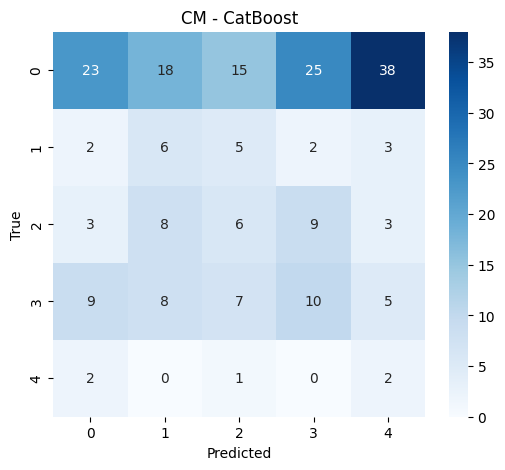

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(y_test, pred_cb, title="CM - CatBoost")


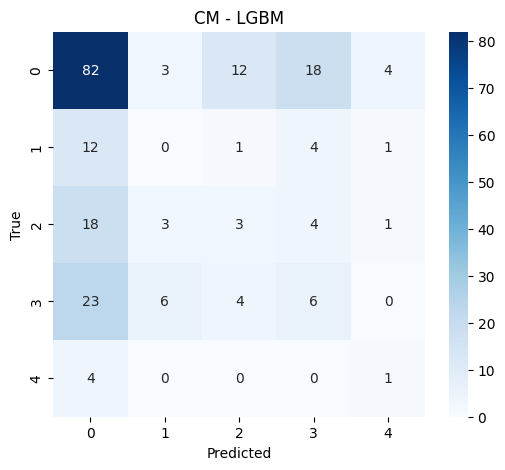

In [10]:
plot_cm(y_test, pred_lgbm, title="CM - LGBM")

## 9. K-Fold로 점수 안정화(선택)

- 왜? 샘플 ~1,050면 폴드에 따라 변동이 큼. Macro F1 평균/표준편차로 신뢰도 확보.

- 설명: 단일 홀드아웃 편차를 줄이고, 모델/전처리 선택을 더 안정적으로 비교.

In [11]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_scores = []
for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]

    cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols]
    cb = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1:average=Macro',
        auto_class_weights='Balanced',
        depth=8, learning_rate=0.06, iterations=1000,
        random_seed=RANDOM_STATE, verbose=False
    )
    cb.fit(Pool(X_tr, y_tr, cat_features=cat_idx), eval_set=Pool(X_va, y_va, cat_features=cat_idx), use_best_model=True, verbose=False)
    pred = cb.predict(Pool(X_va, cat_features=cat_idx)).astype(int).ravel()
    fold_scores.append(f1_score(y_va, pred, average='macro'))
    print(f"Fold{fold} Macro F1: {fold_scores[-1]:.4f}")

print("CV Macro F1 avg±std:", f"{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Fold1 Macro F1: 0.1851
Fold2 Macro F1: 0.1891
Fold3 Macro F1: 0.2012
Fold4 Macro F1: 0.1688
Fold5 Macro F1: 0.2254
CV Macro F1 avg±std: 0.1939 ± 0.0188


## 10. (옵션) severity가 서열형일 때 간단 대안

- 왜? 등급 간 거리가 의미가 있다면 회귀→구간화도 실용적. (정교한 ordinal loss는 별도 라이브러리 필요)

- 설명: 정답과의 거리를 직접 학습. 라운딩 후 분류 지표로 비교. 순정 ordinal 모델보다 단순하지만, 등급 간 유사성 반영 효과가 있음.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 회귀로 학습
rf_reg = RandomForestRegressor(
    n_estimators=600, random_state=RANDOM_STATE, n_jobs=-1
)
# 간단: 숫자/원핫 전처리 재사용
X_ohe = pd.get_dummies(X, columns=cat_cols, dummy_na=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_ohe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

rf_reg.fit(X_tr, y_tr)
pred_reg = rf_reg.predict(X_te)
mae = mean_absolute_error(y_te, pred_reg)
# 등급으로 반올림
pred_bins = np.rint(pred_reg).astype(int)
print(f"[Ordinal-ish] MAE (regression): {mae:.3f}")
print(f"[Ordinal-ish] Macro F1(after rounding): {f1_score(y_te, pred_bins, average='macro'):.4f}")

[Ordinal-ish] MAE (regression): 1.203
[Ordinal-ish] Macro F1(after rounding): 0.0832


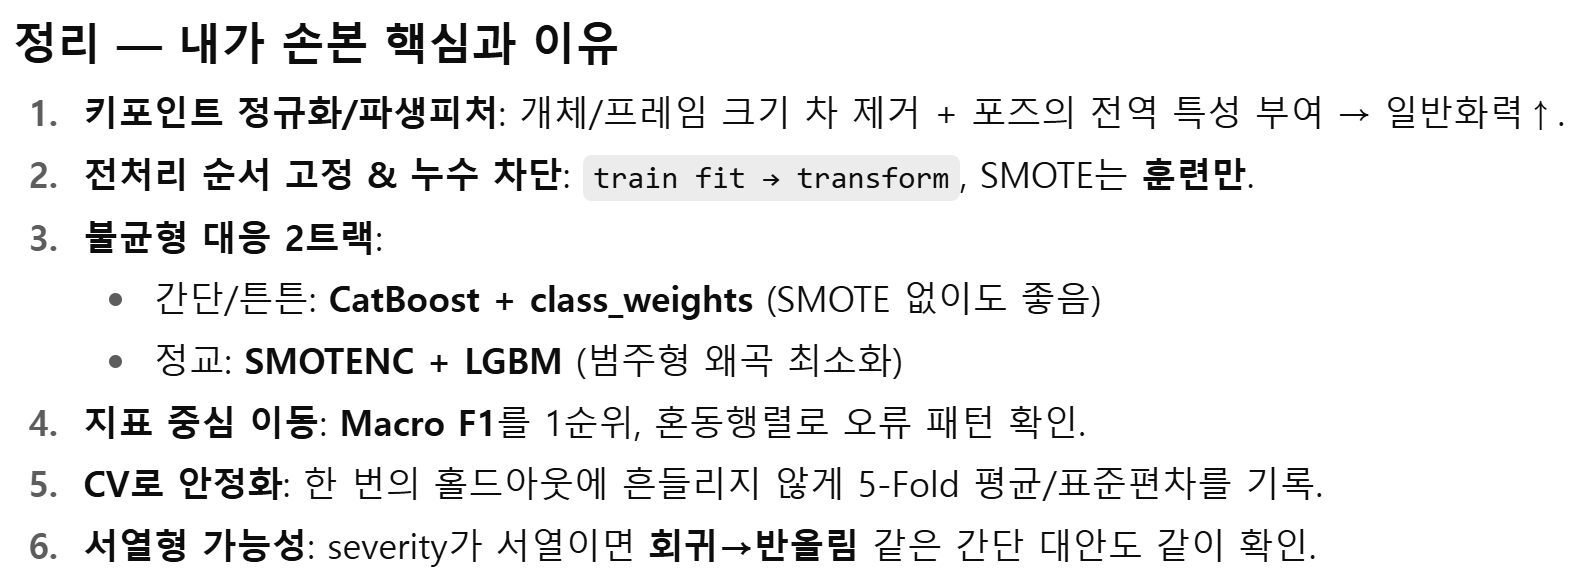